In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm

In [141]:
mu1, mu2, mu3 = 0, 50, 100
sigma1, sigma2, sigma3 = 1, 10, 5
n = 1000
w = [0.1, 0.6, 0.3]

x1 = np.random.normal(mu1, sigma1, n)
x2 = np.random.normal(mu2, sigma2, n)
x3 = np.random.normal(mu3, sigma3, n)

choice = np.random.choice(3, size=n, p=[0.1,0.6,0.3])

x = np.choose(choice, [x1, x2, x3])

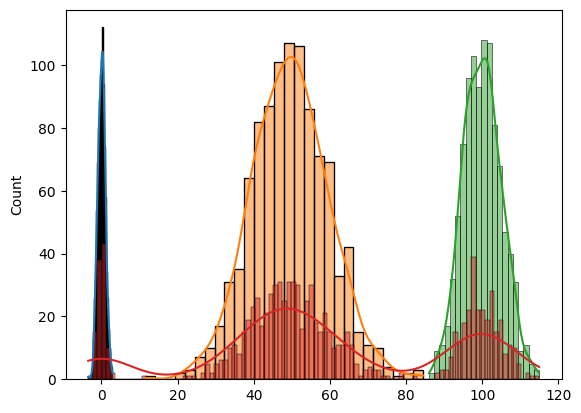

In [145]:
sns.histplot(x1, kde=True)
sns.histplot(x2, kde=True)
sns.histplot(x3, kde=True)
sns.histplot(x, kde=True, bins=100)

plt.show()

In [146]:
w = np.array([0.9, 0.05, 0.05])
mu = np.random.choice(x, 3)
sigma = np.array([x.std(), x.std(), x.std()])
loglik = 0
max_attempts = 1000

for j in range(max_attempts):
    # E-step
    pdf = norm.pdf(x[:, None], mu, sigma)
    weighted = w * pdf
    pi = weighted / weighted.sum(axis=1, keepdims=True)

    Nk = pi.sum(axis=0)

    # M-step
    w = Nk / n
    mu_new = (pi * x[:, None]).sum(axis=0) / Nk
    sigma_new = np.sqrt((pi * (x[:, None] - mu_new)**2).sum(axis=0) / Nk)
    loglik_new = np.sum(np.log(weighted.sum(axis=1)))

    print(f"{j} W {w}, mu {mu}, sigma {sigma}, loglik {loglik}")

    if abs(loglik - loglik_new) < 0.00001:
        break
    else:
        loglik = loglik_new
        mu = mu_new
        sigma = sigma_new

0 W [0.63764514 0.32771047 0.03464439], mu [-0.86179487 57.5679407  -1.33581481], sigma [31.30365278 31.30365278 31.30365278], loglik 0
1 W [0.6393588  0.32589453 0.03474667], mu [45.10960813 85.34237222 44.78633148], sigma [25.85320728 23.01964606 25.84967338], loglik -6137.09856597697
2 W [0.64397092 0.32102289 0.03500619], mu [44.56773597 86.68629627 44.25583122], sigma [25.4003321  21.80781328 25.39588118], loglik -4850.097980844748
3 W [0.65094103 0.31366587 0.03539311], mu [44.05436433 88.40966481 43.75942702], sigma [24.71233123 20.59319984 24.71489975], loglik -4846.181362283274
4 W [0.66096217 0.3030949  0.03594292], mu [43.5621426  90.52534821 43.28551693], sigma [23.90528577 18.94407014 23.92727641], loglik -4840.123003128614
5 W [0.67425079 0.28908551 0.0366637 ], mu [43.13467296 93.14499216 42.87205394], sigma [23.01180286 16.46831673 23.07152402], loglik -4829.323002075012
6 W [0.686356   0.27633239 0.03731161], mu [42.84526763 96.28147171 42.57815607], sigma [22.09509972

In [147]:
from sklearn.mixture import GaussianMixture

# data must be 2D
X = x.reshape(-1, 1)

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=0
)

gmm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


In [148]:
gmm.weights_

array([0.28419537, 0.10899803, 0.60680661])

In [149]:
gmm.means_

array([[9.98967545e+01],
       [5.66095328e-02],
       [4.92524982e+01]])

In [152]:
gmm.covariances_

array([[[ 24.61924241]],

       [[  1.12503572]],

       [[101.57194678]]])

In [153]:
gmm.score(X)          # average log likelihood

-4.18381254359667

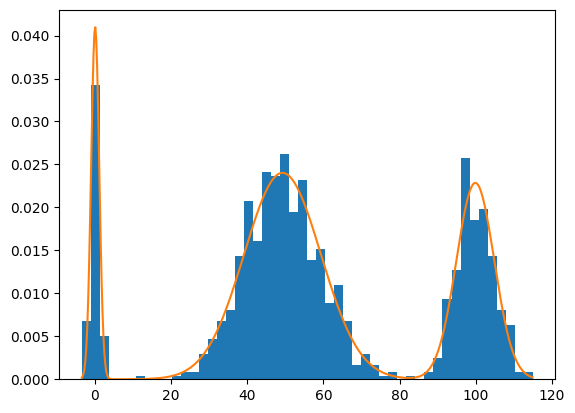

In [154]:
import matplotlib.pyplot as plt
from scipy.stats import norm

x_grid = np.linspace(x.min(), x.max(), 500)

pdf = np.zeros_like(x_grid)

for w, m, s in zip(gmm.weights_, gmm.means_.flatten(), np.sqrt(gmm.covariances_.flatten())):
    pdf += w * norm.pdf(x_grid, m, s)

plt.hist(x, bins=50, density=True)
plt.plot(x_grid, pdf)
plt.show()